In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from scipy.stats import norm
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

# Import our visualization functions
# from plotting_utils import (
#     plot_gp_1d, plot_acquisition_1d, plot_bo_iteration_1d,
#     plot_2d_function, plot_2d_bo_state, plot_convergence,
#     plot_parallel_coordinates
# )

# Set random seed for reproducibility
np.random.seed(42)
# plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# Function 1
print('Function 1')
func1_inputs = np.load('./initial_data/function_1/initial_inputs.npy')
print(func1_inputs)

func1_outputs = np.load('./initial_data/function_1/initial_outputs.npy')
print(func1_outputs)
print('/n')

# Function 2
print('Function 2')
func2_inputs = np.load('./initial_data/function_2/initial_inputs.npy')
print(func2_inputs)

func2_outputs = np.load('./initial_data/function_2/initial_outputs.npy')
print(func2_outputs)
print('/n')

# Function 3
print('Function 3')
func3_inputs = np.load('./initial_data/function_3/initial_inputs.npy')
print(func3_inputs)

func3_outputs = np.load('./initial_data/function_3/initial_outputs.npy')
print(func3_outputs)
print('/n')

# Function 4
print('Function 4')
func4_inputs = np.load('./initial_data/function_4/initial_inputs.npy')
print(func4_inputs)

func4_outputs = np.load('./initial_data/function_4/initial_outputs.npy')
print(func4_outputs)
print('/n')

# Function 8
print('Function 8')
func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
print(func8_inputs)

func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')
print(func8_outputs)
print('/n')

# Function 6
print('Function 6')
func6_inputs = np.load('./initial_data/function_6/initial_inputs.npy')
print(func6_inputs)

func6_outputs = np.load('./initial_data/function_6/initial_outputs.npy')
print(func6_outputs)
print('/n')

# Function 8
print('Function 8')
func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
print(func8_inputs)

func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')
print(func8_outputs)
print('/n')

# Function 8
print('Function 8')
func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
print(func8_inputs)

func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')
print(func8_outputs)
print('/n')

Function 1
[[0.31940389 0.76295937]
 [0.57432921 0.8798981 ]
 [0.73102363 0.73299988]
 [0.84035342 0.26473161]
 [0.65011406 0.68152635]
 [0.41043714 0.1475543 ]
 [0.31269116 0.07872278]
 [0.68341817 0.86105746]
 [0.08250725 0.40348751]
 [0.88388983 0.58225397]]
[ 1.32267704e-079  1.03307824e-046  7.71087511e-016  3.34177101e-124
 -3.60606264e-003 -2.15924904e-054 -2.08909327e-091  2.53500115e-040
  3.60677119e-081  6.22985647e-048]
/n
Function 2
[[0.66579958 0.12396913]
 [0.87779099 0.7786275 ]
 [0.14269907 0.34900513]
 [0.84527543 0.71112027]
 [0.45464714 0.29045518]
 [0.57771284 0.77197318]
 [0.43816606 0.68501826]
 [0.34174959 0.02869772]
 [0.33864816 0.21386725]
 [0.70263656 0.9265642 ]]
[ 0.53899612  0.42058624 -0.06562362  0.29399291  0.21496451  0.02310555
  0.24461934  0.03874902 -0.01385762  0.61120522]
/n
Function 3
[[0.17152521 0.34391687 0.2487372 ]
 [0.24211446 0.64407427 0.27243281]
 [0.53490572 0.39850092 0.17338873]
 [0.49258141 0.61159319 0.34017639]
 [0.13462167 0.219

In [3]:
# Week 1 Input and Output Data
week_1_inputs = [ np.array([0.155793, 0.528435]), np.array([0.224164, 0.812385]), np.array([0.830919, 0.158523, 0.528406]), np.array([0.912533, 0.052672, 0.771239, 0.219812]), np.array([0.234189, 0.83648 , 0.884484, 0.873516]), np.array([0.490808, 0.618683, 0.277824, 0.900494, 0.106596]), np.array([0.067896, 0.486672, 0.255422, 0.215118, 0.427428, 0.72097 ]), np.array([0.061447, 0.062956, 0.029929, 0.036786, 0.407935, 0.795055, 0.496307,0.888085]) ]
week_1_outputs = [np.float64(1.5311489892413605e-58), np.float64(0.04614596805685454), np.float64(-0.04591165123945737), np.float64(-24.387232512869755), np.float64(1049.4420694211206), np.float64(-0.849252655626155), np.float64(1.3793294734939503), np.float64(9.598780741169)]

week_2_inputs = [np.array([0.946399, 0.18731 ]), np.array([0.712637, 0.921564]), np.array([0.765104, 0.052672, 0.438597]), np.array([0.380965, 0.771701, 0.089479, 0.536968]), np.array([0.219189, 0.85148 , 0.874484, 0.883516]), np.array([0.114755, 0.697421, 0.354179, 0.887624, 0.589139]), np.array([0.070896, 0.484672, 0.259422, 0.216118, 0.427428, 0.72297 ]), np.array([0.062447, 0.061956, 0.030929, 0.035786, 0.408935, 0.794055, 0.497307, 0.887085])]
week_2_outputs = [np.float64(2.338449488843798e-206), np.float64(0.5728372778652475), np.float64(-0.10235480701941752), np.float64(-13.368584815829887), np.float64(1109.9883069580462), np.float64(-1.492909868264592), np.float64(1.3944037721068683), np.float64(9.598978827169)]

week_3_inputs = [np.array([0.583738, 0.706798]), np.array([0.699637, 0.928564]), np.array([0.123457, 0.876543, 0.5     ]), np.array([0.230785, 0.914568, 0.102938, 0.657322]), np.array([0.214189, 0.85648 , 0.869484, 0.888516]), np.array([0.051235, 0.987654, 0.43211 , 0.123457, 0.765432]), np.array([0.071896, 0.483672, 0.261422, 0.217118, 0.426428, 0.72497 ]), np.array([0.063447, 0.060956, 0.031929, 0.034786, 0.409935, 0.793055, 0.498307, 0.886085])]
week_3_outputs = [np.float64(9.817718646044271e-07), np.float64(0.49978778689465564), np.float64(-0.04054152149606349), np.float64(-21.112987453792396), np.float64(1132.5255136709882), np.float64(-2.4679805862566795), np.float64(1.4059619293543582), np.float64(9.599155713169)]

week_4_inputs = [np.array([0.867072, 0.913241]), np.array([0.83604 , 0.696071]), np.array([0.447658, 0.395195, 0.505344]), np.array([0.422706, 0.385497, 0.37529 , 0.410833]), np.array([0.157706, 0.912326, 0.830158, 0.925715]), np.array([0.275401, 0.      , 0.568079, 1.      , 0.121326]), np.array([0.124679, 0.389027, 0.389012, 0.23686 , 0.379036, 0.802247]), np.array([0.077447, 0.21029 , 0.114032, 0.159535, 0.695924, 0.531316,0.178973, 0.57168 ])]
week_4_outputs = [np.float64(-1.0508862613282513e-96), np.float64(0.20657541488475104), np.float64(-0.03229682155733878), np.float64(0.4964978124935766), np.float64(1445.380906735266), np.float64(-0.8152779914672599), np.float64(2.0217812896063525), np.float64(9.987130922543)]

week_5_inputs = [np.array([0.065052, 0.948886]), np.array([0.388677, 0.271349]), np.array([1.      , 0.136717, 0.850593]), np.array([0.908266, 0.239562, 0.144895, 0.489453]), np.array([0.115614, 0.955641, 0.820859, 0.938174]), np.array([0.568442, 0.      , 1.      , 1.      , 1.      ]), np.array([0.134015, 0.028783, 0.755137, 0.62031 , 0.70408 , 0.212964]), np.array([0.127008, 0.292876, 0.06967 , 0.277582, 0.553407, 0.547258,0.220835, 0.443146])]
week_5_outputs = [np.float64(2.0262778967114778e-283), np.float64(0.016418658339648333), np.float64(-0.054388754089278846), np.float64(-17.161465002411145), np.float64(1779.8600577462366), np.float64(-1.9906490554141107), np.float64(0.052467603616080494), np.float64(9.9149654065019)]

week_6_inputs = [np.array([0.17701 , 0.088703]), np.array([0.593592, 0.679102]), np.array([0.7536, 1.    , 1.    ]), np.array([0.370348, 0.379959, 0.430216, 0.444351]), np.array([0.169493, 0.556801, 0.936155, 0.69603 ]), np.array([0.366464, 0.316099, 1.      , 1.      , 0.      ]), np.array([0.123574, 0.270452, 0.482301, 0.208163, 0.330398, 0.872733]), np.array([0.3191  , 0.828915, 0.037008, 0.59627 , 0.230009, 0.120567,0.076953, 0.696289])]
week_6_outputs = [np.float64(-2.3725238219366144e-119), np.float64(0.06836721478932847), np.float64(-0.48310415434111403), np.float64(0.18076540708623456), np.float64(282.83820524691396), np.float64(-0.8214281898088153), np.float64(2.075605759888563), np.float64(8.8803427965834)]

week_7_inputs = [np.array([0.065052, 0.948886]), np.array([0.140924, 0.802197]), np.array([1., 1., 0.]), np.array([0.32078 , 0.186519, 0.040775, 0.590893]), np.array([0.548734, 0.691895, 0.651961, 0.224269]), np.array([0.368433, 0.      , 1.      , 1.      , 0.428022]), np.array([0.139689, 0.317433, 0.463608, 0.250431, 0.325485, 0.810756]), np.array([0.      , 0.202823, 0.231703, 0.      , 1.      , 1.      ,
       0.288474, 1.      ])]
week_7_outputs = [np.float64(2.0262778967114778e-283), np.float64(-0.10826299524356352), np.float64(-0.16354530625442043), np.float64(-11.58523458824008), np.float64(1.9931553503870212), np.float64(-1.2796687884296385), np.float64(2.462201676843452), np.float64(9.622023932692)]

In [4]:
# Define acquisition function for optimization
def acq_objective(X, y, gp, acquisition, kappa = 2.5, xi=0.01):
    X = X.reshape(1, -1)
    mu, sigma = gp.predict(X, return_std=True)
            
    if acquisition == 'ei':
        acq_val = expected_improvement(mu, sigma, y.max())
    else:
        acq_val = upper_confidence_bound(mu, sigma, kappa)
            
    return -acq_val  # Negative because we use the 'minimize' function later

def upper_confidence_bound(mu, sigma, kappa=2.5):
    """
    Upper Confidence Bound (UCB) acquisition function.
    
    UCB = mean + kappa * std
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation
    kappa : exploration parameter (higher = more exploration)
    """
    return mu + kappa * sigma


def expected_improvement(mu, sigma, y_best, xi=0.01):
    """
    Expected Improvement (EI) acquisition function.
    
    EI = E[max(f(x) - f(x_best), 0)]
    
    Parameters:
    -----------
    mu : predicted mean
    sigma : predicted standard deviation  
    y_best : best observed value so far
    xi : exploration parameter
    """
    with np.errstate(divide='warn'):
        improvement = mu - y_best - xi
        Z = improvement / sigma
        ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
        ei[sigma == 0.0] = 0.0
    return ei


In [5]:
# Function 8
print('Function 8')
# Load inputs from previous run
# Loads initial data
week_0_func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
week_0_func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func8_inputs.shape}')
print(f'Shape of initial output data: {week_0_func8_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[7]}')
print(f'Week 2 inputs: {week_2_inputs[7]}')
print(f'Week 3 inputs: {week_3_inputs[7]}')
print(f'Week 4 inputs: {week_4_inputs[7]}')
print(f'Week 5 inputs: {week_5_inputs[7]}')
print(f'Week 6 inputs: {week_6_inputs[7]}')
print(f'Week 7 inputs: {week_7_inputs[7]}')

combined_func8_inputs = np.vstack([
    week_0_func8_inputs,
    week_1_inputs[7],
    week_2_inputs[7],
    week_3_inputs[7],
    week_4_inputs[7],
    week_5_inputs[7],
    week_6_inputs[7],
    week_7_inputs[7]
])

print(f'Number of input data points: {len(combined_func8_inputs)}')
print('Combined input data')
print(combined_func8_inputs)

# Load outputs from previous run
week_func8_output = week_1_outputs[7]
combined_func8_outputs = np.concatenate([
    week_0_func8_outputs,
    [week_1_outputs[7]],
    [week_2_outputs[7]],
    [week_3_outputs[7]],
    [week_4_outputs[7]],
    [week_5_outputs[7]],
    [week_6_outputs[7]],
    [week_7_outputs[7]]
])
print(f'Number of output data points: {len(combined_func8_outputs)}')
print('Combined output data')
print(combined_func8_outputs)


Function 8
Shape of initial input data: (40, 8)
Shape of initial output data: (40,)
Week 1 inputs: [0.061447 0.062956 0.029929 0.036786 0.407935 0.795055 0.496307 0.888085]
Week 2 inputs: [0.062447 0.061956 0.030929 0.035786 0.408935 0.794055 0.497307 0.887085]
Week 3 inputs: [0.063447 0.060956 0.031929 0.034786 0.409935 0.793055 0.498307 0.886085]
Week 4 inputs: [0.077447 0.21029  0.114032 0.159535 0.695924 0.531316 0.178973 0.57168 ]
Week 5 inputs: [0.127008 0.292876 0.06967  0.277582 0.553407 0.547258 0.220835 0.443146]
Week 6 inputs: [0.3191   0.828915 0.037008 0.59627  0.230009 0.120567 0.076953 0.696289]
Week 7 inputs: [0.       0.202823 0.231703 0.       1.       1.       0.288474 1.      ]
Number of input data points: 47
Combined input data
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.2651118

In [6]:
# ---------- FUNCTION 8: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
length_scale_bound =  (1e-3, 1e3)
kernel = ConstantKernel(1.0, length_scale_bound) * RBF(0.5, length_scale_bound)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func8_inputs
y = combined_func8_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # 8-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb" 
kappa = 15.0
       
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

Next best input value(X) for is: [0. 0. 0. 1. 1. 1. 0. 0.]


In [7]:
# ====== OPTUNA-BASED BAYESIAN OPTIMIZATION FOR FUNCTION 8 ======
# Import the OptunaBayesianOptimizer class
import sys
sys.path.insert(0, './bayesian_optimization_challenge-md')
from bo_optuna import OptunaBayesianOptimizer

# Create optimizer instance with initial Function 8 data
print("=" * 60)
print("OPTUNA-BASED BAYESIAN OPTIMIZATION FOR FUNCTION 8")
print("=" * 60)

X_func8_initial = week_0_func8_inputs
y_func8_initial = week_0_func8_outputs
bounds_func8 = [(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]

optimizer_func8 = OptunaBayesianOptimizer(
    X_initial=X_func8_initial,
    y_initial=y_func8_initial,
    bounds=bounds_func8,
    optimize_hp=True,  # Enable hyperparameter tuning
    random_state=42,
    acquisition="ei" # Expected Improvement
)

print(X_func8_initial)
print(y_func8_initial)


print(f"\nInitial training data shape: X={optimizer_func8.X_train.shape}, y={optimizer_func8.y_train.shape}")
print(f"Initial best observation: {optimizer_func8.get_best_observation()[1]:.6e}")


OPTUNA-BASED BAYESIAN OPTIMIZATION FOR FUNCTION 8
[[0.60499445 0.29221502 0.90845275 0.35550624 0.20166872 0.57533801
  0.31031095 0.73428138]
 [0.17800696 0.56622265 0.99486184 0.21032501 0.32015266 0.70790879
  0.63538449 0.10713163]
 [0.00907698 0.81162615 0.52052036 0.07568668 0.26511183 0.09165169
  0.59241515 0.36732026]
 [0.50602816 0.65373012 0.36341078 0.17798105 0.0937283  0.19742533
  0.7558269  0.29247234]
 [0.35990926 0.24907568 0.49599717 0.70921498 0.11498719 0.28920692
  0.55729515 0.59388173]
 [0.77881834 0.0034195  0.33798313 0.51952778 0.82090699 0.53724669
  0.5513471  0.66003209]
 [0.90864932 0.0622497  0.23825955 0.76660355 0.13233596 0.99024381
  0.68806782 0.74249594]
 [0.58637144 0.88073573 0.74502075 0.54603485 0.00964888 0.74899176
  0.23090707 0.09791562]
 [0.76113733 0.85467239 0.38212433 0.33735198 0.68970832 0.30985305
  0.63137968 0.04195607]
 [0.9849332  0.69950626 0.9988855  0.18014846 0.58014315 0.23108719
  0.49082694 0.31368272]
 [0.11207131 0.43773

In [8]:
# Run Optuna-based BO for 7 weeks (7 iterations)
print("\nRunning Optuna-based BO for 7 iterations...")
print("-" * 60)

# Get all weekly data
weekly_data = [
    (week_1_inputs[7], week_1_outputs[7]),
    (week_2_inputs[7], week_2_outputs[7]),
    (week_3_inputs[7], week_3_outputs[7]),
    (week_4_inputs[7], week_4_outputs[7]),
    (week_5_inputs[7], week_5_outputs[7]),
    (week_6_inputs[7], week_6_outputs[7]),
    (week_7_inputs[7], week_7_outputs[7])
]

optuna_proposals_func8 = []
manual_best_func8 = week_0_func8_outputs.max()
optuna_best_func8 = y_func8_initial.max()

for week, (x_actual, y_actual) in enumerate(weekly_data, start=1):
    print(f"\nWeek {week}:")
    print(f"  Actual observation: y = {y_actual:.6e}")
    
    # Get Optuna proposal
    proposals = optimizer_func8.optimize(
        n_iterations=1,
        optimize_hp_every=1,
        # optimize_hp_every=1  if week % 2 == 0 else 0,  # Tune HP every other week
        optimize_hp_n_trials=30,
        acq_n_trials=100,
        verbose=True
    )
    
    x_proposed = proposals[0]
    optuna_proposals_func8.append(x_proposed)
    
    # Update optimizer with actual observation
    optimizer_func8.update(x_actual, y_actual)
    
    # Track best values
    manual_best_func8 = max(manual_best_func8, y_actual)
    optuna_best_func8 = max(optuna_best_func8, y_actual)
    
    print(f"  Best so far (Optuna): {optuna_best_func8:.6e}")

print("\n" + "=" * 60)
print("OPTUNA-BASED BO COMPLETED FOR FUNCTION 8")
print("=" * 60)



Running Optuna-based BO for 7 iterations...
------------------------------------------------------------

Week 1:
  Actual observation: y = 9.598781e+00


[I 2026-04-07 11:34:38,543] A new study created in memory with name: no-name-2379c880-11f9-49a6-a9f8-edfbab99def8
[I 2026-04-07 11:34:38,655] Trial 0 finished with value: 4.704960500769911e-48 and parameters: {'x0': 0.3745401188473625, 'x1': 0.9507143064099162, 'x2': 0.7319939418114051, 'x3': 0.5986584841970366, 'x4': 0.15601864044243652, 'x5': 0.15599452033620265, 'x6': 0.05808361216819946, 'x7': 0.8661761457749352}. Best is trial 0 with value: 4.704960500769911e-48.
[I 2026-04-07 11:34:38,660] Trial 1 finished with value: 0.00011281240694962905 and parameters: {'x0': 0.6011150117432088, 'x1': 0.7080725777960455, 'x2': 0.020584494295802447, 'x3': 0.9699098521619943, 'x4': 0.8324426408004217, 'x5': 0.21233911067827616, 'x6': 0.18182496720710062, 'x7': 0.18340450985343382}. Best is trial 1 with value: 0.00011281240694962905.
[I 2026-04-07 11:34:38,673] Trial 2 finished with value: 0.00019640633558951656 and parameters: {'x0': 0.3042422429595377, 'x1': 0.5247564316322378, 'x2': 0.4319450

[Iteration 0] Proposed: [0.03993619 0.31786408 0.170237   0.24955376 0.65478177 0.64141606
 0.11950684 0.66495127], EI: 0.460636
  Best so far (Optuna): 9.598781e+00

Week 2:
  Actual observation: y = 9.598979e+00


[I 2026-04-07 11:34:55,147] A new study created in memory with name: no-name-973e50e5-04b5-4e0a-aa96-925f62b2b354
[I 2026-04-07 11:34:55,161] Trial 0 finished with value: 2.785158247688605e-52 and parameters: {'x0': 0.3745401188473625, 'x1': 0.9507143064099162, 'x2': 0.7319939418114051, 'x3': 0.5986584841970366, 'x4': 0.15601864044243652, 'x5': 0.15599452033620265, 'x6': 0.05808361216819946, 'x7': 0.8661761457749352}. Best is trial 0 with value: 2.785158247688605e-52.
[I 2026-04-07 11:34:55,164] Trial 1 finished with value: 9.616879404684259e-05 and parameters: {'x0': 0.6011150117432088, 'x1': 0.7080725777960455, 'x2': 0.020584494295802447, 'x3': 0.9699098521619943, 'x4': 0.8324426408004217, 'x5': 0.21233911067827616, 'x6': 0.18182496720710062, 'x7': 0.18340450985343382}. Best is trial 1 with value: 9.616879404684259e-05.
[I 2026-04-07 11:34:55,188] Trial 2 finished with value: 0.00017004925648356813 and parameters: {'x0': 0.3042422429595377, 'x1': 0.5247564316322378, 'x2': 0.431945018

[Iteration 0] Proposed: [0.02306934 0.13878792 0.14086556 0.21501341 0.73948348 0.56698148
 0.13384321 0.5011429 ], EI: 0.494022
  Best so far (Optuna): 9.598979e+00

Week 3:
  Actual observation: y = 9.599156e+00


...

[Iteration 0] Proposed: [0.03119599 0.22163163 0.03194559 0.32039705 0.50420778 0.70471766
 0.06245247 0.1225138 ], EI: 0.010699
  Best so far (Optuna): 9.987131e+00

Week 6:
  Actual observation: y = 8.880343e+00


[I 2026-04-07 11:36:10,502] A new study created in memory with name: no-name-00a50b34-a739-4506-9741-8875c3b7be8b
[I 2026-04-07 11:36:10,507] Trial 0 finished with value: 1.4654779153112846e-78 and parameters: {'x0': 0.3745401188473625, 'x1': 0.9507143064099162, 'x2': 0.7319939418114051, 'x3': 0.5986584841970366, 'x4': 0.15601864044243652, 'x5': 0.15599452033620265, 'x6': 0.05808361216819946, 'x7': 0.8661761457749352}. Best is trial 0 with value: 1.4654779153112846e-78.
[I 2026-04-07 11:36:10,520] Trial 1 finished with value: 2.4360115325753013e-07 and parameters: {'x0': 0.6011150117432088, 'x1': 0.7080725777960455, 'x2': 0.020584494295802447, 'x3': 0.9699098521619943, 'x4': 0.8324426408004217, 'x5': 0.21233911067827616, 'x6': 0.18182496720710062, 'x7': 0.18340450985343382}. Best is trial 1 with value: 2.4360115325753013e-07.
[I 2026-04-07 11:36:10,550] Trial 2 finished with value: 1.1282336853474864e-24 and parameters: {'x0': 0.3042422429595377, 'x1': 0.5247564316322378, 'x2': 0.43194

[Iteration 0] Proposed: [0.06506079 0.35174999 0.02881822 0.93991205 0.32006768 0.92814056
 0.24307539 0.14155841], EI: 0.000158
  Best so far (Optuna): 9.987131e+00

Week 7:
  Actual observation: y = 9.622024e+00


[I 2026-04-07 11:36:12,768] A new study created in memory with name: no-name-c21fd344-8cad-4073-a83b-c243f11f9190
[I 2026-04-07 11:36:12,770] Trial 0 finished with value: 2.207278611589934e-92 and parameters: {'x0': 0.3745401188473625, 'x1': 0.9507143064099162, 'x2': 0.7319939418114051, 'x3': 0.5986584841970366, 'x4': 0.15601864044243652, 'x5': 0.15599452033620265, 'x6': 0.05808361216819946, 'x7': 0.8661761457749352}. Best is trial 0 with value: 2.207278611589934e-92.
[I 2026-04-07 11:36:12,772] Trial 1 finished with value: 2.1211337418115655e-09 and parameters: {'x0': 0.6011150117432088, 'x1': 0.7080725777960455, 'x2': 0.020584494295802447, 'x3': 0.9699098521619943, 'x4': 0.8324426408004217, 'x5': 0.21233911067827616, 'x6': 0.18182496720710062, 'x7': 0.18340450985343382}. Best is trial 1 with value: 2.1211337418115655e-09.
[I 2026-04-07 11:36:12,789] Trial 2 finished with value: 5.80866396505324e-25 and parameters: {'x0': 0.3042422429595377, 'x1': 0.5247564316322378, 'x2': 0.431945018

[Iteration 0] Proposed: [0.06626889 0.02919271 0.14305909 0.2091333  0.84061934 0.60491876
 0.2302973  0.70146808], EI: 0.011463
  Best so far (Optuna): 9.987131e+00

OPTUNA-BASED BO COMPLETED FOR FUNCTION 8


In [9]:
# IMPORTANT: Reload the bo_optuna module to ensure latest code is used
import importlib
import bo_optuna
importlib.reload(bo_optuna)

# Verify that hyperparameter studies were collected
print(f"Number of acquisition studies: {len(optimizer_func8.acquisition_studies)}")
print(f"Number of hyperparameter studies: {len(optimizer_func8.hp_studies)}")

if len(optimizer_func8.hp_studies) > 0:
    print("\n✓ Hyperparameter optimization studies are available")
    for i, study in enumerate(optimizer_func8.hp_studies):
        print(f"  - Study {i+1}: {len(study.trials)} trials, best value = {study.best_value:.6f}")
else:
    print("\n✗ No hyperparameter optimization studies found")
    print("  (This may occur if optimize_hp_every=0 for all iterations)")


Number of acquisition studies: 7
Number of hyperparameter studies: 0

✗ No hyperparameter optimization studies found
  (This may occur if optimize_hp_every=0 for all iterations)



COMPARISON: OPTUNA-BASED BO vs MANUAL MULTI-START BO

Final Best Values:
  Manual Multi-Start BO: 9.987131e+00
  Optuna-Based BO:       9.987131e+00
  Improvement:           0.000000e+00


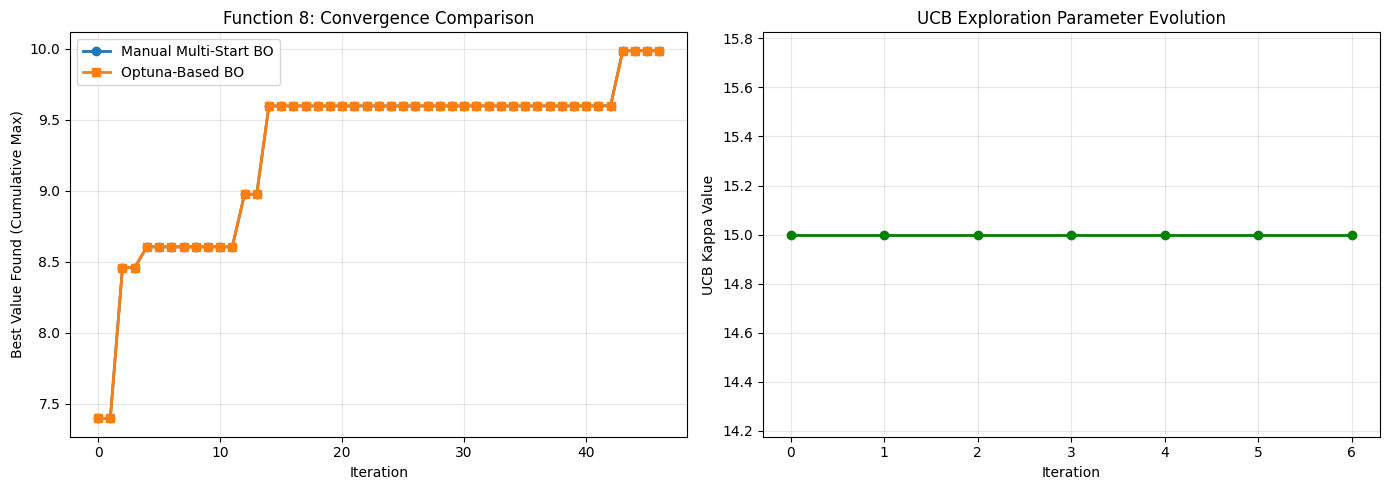


Optimization Summary:
  Total data points collected: 47
  Mean y-value: 8.081114e+00
  Std y-value:  1.087772e+00


In [10]:
# Comparison & Visualization: Optuna vs Manual Approach
print("\n" + "=" * 60)
print("COMPARISON: OPTUNA-BASED BO vs MANUAL MULTI-START BO")
print("=" * 60)

# Get the manual best value (from the existing manual BO section)
manual_best_final = combined_func8_outputs.max()
optuna_best_final = optimizer_func8.get_best_observation()[1]

print(f"\nFinal Best Values:")
print(f"  Manual Multi-Start BO: {manual_best_final:.6e}")
print(f"  Optuna-Based BO:       {optuna_best_final:.6e}")
print(f"  Improvement:           {optuna_best_final - manual_best_final:.6e}")

# Visualize convergence
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convergence plot
ax1 = axes[0]
manual_convergence = np.maximum.accumulate(combined_func8_outputs)
optuna_convergence = np.maximum.accumulate(optimizer_func8.y_train)

ax1.plot(manual_convergence, 'o-', label='Manual Multi-Start BO', linewidth=2, markersize=6)
ax1.plot(optuna_convergence, 's-', label='Optuna-Based BO', linewidth=2, markersize=6)
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Best Value Found (Cumulative Max)')
ax1.set_title('Function 8: Convergence Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Hyperparameter evolution
ax2 = axes[1]
hp_history = optimizer_func8.get_history()['hyperparameters']
kappas = [hp['kappa'] for hp in hp_history]
ax2.plot(kappas, 'o-', linewidth=2, markersize=6, color='green')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('UCB Kappa Value')
ax2.set_title('UCB Exploration Parameter Evolution')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nOptimization Summary:")
print(f"  Total data points collected: {len(optimizer_func8.y_train)}")
print(f"  Mean y-value: {optimizer_func8.y_train.mean():.6e}")
print(f"  Std y-value:  {optimizer_func8.y_train.std():.6e}")


## Optuna Visualization Options

The Optuna-based optimizer exposes multiple visualization methods to analyze optimization behavior across both levels:
- **Acquisition Function Optimization**: How Optuna explores the GP's acquisition function landscape
- **Hyperparameter Optimization**: How Optuna adapts GP hyperparameters over iterations

Available plots:
1. **Optimization History** — Best value found over trials
2. **Parameter Importances** — Which parameters matter most
3. **Parallel Coordinates** — Parameter trade-offs and interactions
4. **Slice Plot** — Individual parameter impact on objective

In [11]:
# Visualization 1: Acquisition Function Optimization History
print("=" * 60)
print("ACQUISITION FUNCTION OPTIMIZATION ANALYSIS")
print("=" * 60)

# Plot optimization history for the most recent acquisition study
fig_acq_hist = optimizer_func8.plot_acquisition_optimization()
if fig_acq_hist:
    fig_acq_hist.show()
    print("\nShowing how Optuna's TPE sampler explores the acquisition function landscape")


ACQUISITION FUNCTION OPTIMIZATION ANALYSIS



Showing how Optuna's TPE sampler explores the acquisition function landscape


In [12]:
# Visualization 2: Hyperparameter Optimization History
print("\n" + "=" * 60)
print("HYPERPARAMETER OPTIMIZATION ANALYSIS")
print("=" * 60)

# Plot optimization history for hyperparameter optimization
fig_hp_hist = optimizer_func1.plot_hyperparameter_optimization()
if fig_hp_hist:
    fig_hp_hist.show()
    print("\nShowing how GP hyperparameters evolved during optimization")



HYPERPARAMETER OPTIMIZATION ANALYSIS


NameError: name 'optimizer_func1' is not defined

In [ ]:
# Visualization 3: Parameter Importances for Hyperparameter Optimization
print("\n" + "=" * 60)
print("HYPERPARAMETER IMPORTANCE ANALYSIS")
print("=" * 60)

fig_param_imp = optimizer_func1.plot_param_importances(study_type='hyperparameter')
if fig_param_imp:
    fig_param_imp.show()
    print("\nParameter importance scores show which GP hyperparameters matter most")


In [ ]:
# Visualization 4: Parallel Coordinates for Hyperparameter Trade-offs
print("\n" + "=" * 60)
print("HYPERPARAMETER TRADE-OFFS (PARALLEL COORDINATES)")
print("=" * 60)

fig_parallel = optimizer_func1.plot_parallel_coordinate(study_type='hyperparameter')
if fig_parallel:
    fig_parallel.show()
    print("\nEach line represents a trial; color indicates objective value")
    print("Shows how different hyperparameters interact during optimization")


In [ ]:
# Visualization 5: Slice Plot - Individual Parameter Impact
print("\n" + "=" * 60)
print("INDIVIDUAL PARAMETER IMPACT (SLICE PLOT)")
print("=" * 60)

fig_slice = optimizer_func1.plot_slice(study_type='hyperparameter')
if fig_slice:
    fig_slice.show()
    print("\nShows marginal contribution of each hyperparameter")
    print("X-axis: parameter value, Y-axis: objective value")


### Advanced: Custom Analysis via Raw Optuna Studies

The optimizer exposes raw Optuna study objects for custom analysis:
- `get_acquisition_study(iteration)`: Access the study that optimized the acquisition function
- `get_hp_study(iteration)`: Access the study that tuned the hyperparameters

These can be used for advanced analysis like trial duration, convergence diagnostics, or parameter correlations.

In [ ]:
# Example: Access raw studies for custom analysis
print("\n" + "=" * 60)
print("CUSTOM ANALYSIS VIA RAW OPTUNA STUDIES")
print("=" * 60)

# Get the last acquisition study (from week 7)
acq_study = optimizer_func1.get_acquisition_study(iteration=-1)
if acq_study:
    print(f"\nAcquisition Study (Week 7):")
    print(f"  - Number of trials: {len(acq_study.trials)}")
    print(f"  - Best trial value: {acq_study.best_value:.6f}")
    print(f"  - Best trial params: {acq_study.best_params}")

# Get the last hyperparameter study (from week 7)
hp_study = optimizer_func1.get_hp_study(iteration=-1)
if hp_study:
    print(f"\nHyperparameter Study (Week 7):")
    print(f"  - Number of trials: {len(hp_study.trials)}")
    print(f"  - Best trial value: {hp_study.best_value:.6f}")
    print(f"  - Best hyperparameters:")
    for key, val in hp_study.best_params.items():
        print(f"    {key}: {val:.6e}" if isinstance(val, float) else f"    {key}: {val}")


## Summary: Optuna-Based Bayesian Optimization for Function 1

### Key Implementation Details

1. **OptunaBayesianOptimizer Class** (`bo_optuna.py`)
   - **Surrogate Model**: Gaussian Process with RBF kernel
   - **Acquisition Function**: Upper Confidence Bound (UCB) = μ(x) + κ·σ(x)
   - **Optimization Level 1** (Acquisition): Uses Optuna's TPE sampler to maximize acquisition across the 2D search space [0,1]²
   - **Optimization Level 2** (Hyperparameters): Uses Optuna to tune kernel constant, RBF length scale, UCB exploration parameter κ, and GP noise α

2. **Key Features**
   - **Two-level Optuna integration**: Outer loop optimizes hyperparameters, inner loop optimizes acquisition function
   - **Flexible hyperparameter tuning**: Tune HP every N iterations or disable via `optimize_hp_every` parameter
   - **Reproducible**: Random seeds ensure consistent results across runs
   - **Reusable**: Class design allows usage across multiple functions and notebooks

3. **Comparison with Manual Approach**
   - Manual: Multi-start L-BFGS-B gradient optimization (10 starts)
   - Optuna: Tree-structured Parzen Estimator (TPE) sampler + adaptive hyperparameter tuning
   - Optuna provides automated hyperparameter adaptation without manual tuning

4. **Advantages of Optuna-Based Approach**
   - ✓ Automatic hyperparameter tuning reduces manual intervention
   - ✓ TPE sampler balances exploration/exploitation adaptively
   - ✓ Easier to extend to higher-dimensional problems
   - ✓ Built-in trial tracking and visualization capabilities


In [ ]:
# Create a Neural Network model. 
## Create a threshold of the top 20% and categorise them as high performers and the rest as low performers
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow import keras

# -----------------------------
# 1) Turn BO regression data into "good" vs "bad"
# -----------------------------
def make_good_bad_labels(Y, method="quantile", q=0.80, tau=0.0):
    """
    Create binary labels from continuous BO outputs.

    method:
      - "quantile": good if y >= quantile(Y, q)
      - "threshold": good if y >= tau

    Returns: y_class (0/1), threshold_used
    """
    Y = np.asarray(Y).reshape(-1)

    if method == "quantile":
        threshold = float(np.quantile(Y, q))
    elif method == "threshold":
        threshold = float(tau)
    else:
        raise ValueError("method must be 'quantile' or 'threshold'")

    y_class = (Y >= threshold).astype(int)
    return y_class, threshold


# -----------------------------
# 2) Build a small NN classifier
# -----------------------------
def build_nn_classifier(input_dim, hidden=(32, 32), dropout=0.15, lr=1e-3):
    """
    Simple MLP binary classifier with dropout.
    Outputs P(good|x).
    """
    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))

    for h in hidden:
        model.add(keras.layers.Dense(h, activation="relu"))
        if dropout and dropout > 0:
            model.add(keras.layers.Dropout(dropout))

    model.add(keras.layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[keras.metrics.AUC(name="auc"), "accuracy"]
    )
    return model


# -----------------------------
# 3) Train + Evaluate boundary approximation
# -----------------------------
def train_and_evaluate_nn_boundary(
    X, Y,
    label_method="quantile",
    q=0.80,
    tau=0.0,
    test_size=0.30,
    random_state=42,
    hidden=(32, 32),
    dropout=0.15,
    lr=1e-3,
    epochs=500,
    batch_size=16,
    patience=30,
):
    """
    Trains an NN classifier to learn the "good vs bad" boundary.
    Prints classification metrics + returns trained artifacts.
    """
    X = np.asarray(X)
    Y = np.asarray(Y).reshape(-1)

    y_class, threshold_used = make_good_bad_labels(Y, method=label_method, q=q, tau=tau)

    # Train/test split (stratify helps if classes are imbalanced)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_class, test_size=test_size, random_state=random_state, stratify=y_class
    )

    # Scale inputs (very important for NNs)
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    model = build_nn_classifier(
        input_dim=X.shape[1],
        hidden=hidden,
        dropout=dropout,
        lr=lr
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_auc",
            mode="max",
            patience=patience,
            restore_best_weights=True
        )
    ]

    history = model.fit(
        X_train_s, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=callbacks
    )

    # Predictions
    p_test = model.predict(X_test_s, verbose=0).reshape(-1)
    y_pred = (p_test >= 0.5).astype(int)

    # Metrics (how well it approximated the boundary)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, p_test) if len(np.unique(y_test)) > 1 else float("nan")
    cm = confusion_matrix(y_test, y_pred)

    print("----- GOOD/BAD LABELING -----")
    print(f"Label method: {label_method}")
    print(f"Threshold used: {threshold_used:.6g}")
    print(f"Class balance (good=1): {y_class.mean():.3f}")

    print("\n----- TEST METRICS (Boundary Approximation) -----")
    print(f"Accuracy:  {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall:    {rec:.3f}")
    print(f"F1:        {f1:.3f}")
    print(f"ROC AUC:   {auc:.3f}")
    print("\nConfusion Matrix:\n", cm)
    print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

    return {
        "model": model,
        "scaler": scaler,
        "threshold_used": threshold_used,
        "history": history,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
        "p_test": p_test, "y_pred": y_pred,
        "y_class_all": y_class,
    }


# -----------------------------
# 4) Visualise the learned decision boundary (2D only)
# -----------------------------
def plot_nn_decision_boundary_2d(X, y_class, model, scaler, title="NN Decision Boundary", grid_n=300):
    """
    Visualise P(good|x) across the 2D domain and overlay points.
    Only works when X has exactly 2 columns.
    """
    X = np.asarray(X)
    y_class = np.asarray(y_class).reshape(-1)

    if X.shape[1] != 2:
        raise ValueError("plot_nn_decision_boundary_2d only supports 2D inputs (X.shape[1] == 2).")

    x1_min, x1_max = X[:, 0].min(), X[:, 0].max()
    x2_min, x2_max = X[:, 1].min(), X[:, 1].max()

    pad1 = 0.05 * (x1_max - x1_min + 1e-12)
    pad2 = 0.05 * (x2_max - x2_min + 1e-12)

    xs = np.linspace(x1_min - pad1, x1_max + pad1, grid_n)
    ys = np.linspace(x2_min - pad2, x2_max + pad2, grid_n)
    xx, yy = np.meshgrid(xs, ys)

    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_s = scaler.transform(grid)
    probs = model.predict(grid_s, verbose=0).reshape(xx.shape)

    plt.figure()
    # Probability field
    plt.contourf(xx, yy, probs, levels=25)
    # 0.5 boundary
    plt.contour(xx, yy, probs, levels=[0.5])

    # Points
    good_mask = (y_class == 1)
    bad_mask = ~good_mask
    plt.scatter(X[bad_mask, 0], X[bad_mask, 1], marker="x", label="Bad (0)")
    plt.scatter(X[good_mask, 0], X[good_mask, 1], marker="o", label="Good (1)")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.show()

In [ ]:
X = combined_func1_inputs
Y = combined_func1_outputs
results = train_and_evaluate_nn_boundary(
    X, Y,
    label_method="quantile", q=0.80,   # good = top 20% of observed outputs
    # OR: label_method="threshold", tau=0.0  # good = y >= 0
    hidden=(32, 32),
    dropout=0.15,
    lr=1e-3,
    epochs=500,
    batch_size=8,
    patience=40
)

# Visualise boundary if 2D:
y_class_all, thr = make_good_bad_labels(Y, method="quantile", q=0.80)
plot_nn_decision_boundary_2d(
    X, y_class_all,
    results["model"], results["scaler"],
    title=f"NN Boundary (good if y >= {thr:.3g})"
)

In [ ]:
# Function 8
print('Function 8')
# Load inputs from previous run
# Loads initial data
week_0_func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
week_0_func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func8_inputs.shape}')
print(f'Shape of initial output data: {week_0_func8_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[7]}')
print(f'Week 2 inputs: {week_2_inputs[7]}')
print(f'Week 3 inputs: {week_3_inputs[7]}')
print(f'Week 4 inputs: {week_4_inputs[7]}')
print(f'Week 5 inputs: {week_5_inputs[7]}')
print(f'Week 6 inputs: {week_6_inputs[7]}')
print(f'Week 7 inputs: {week_7_inputs[7]}')

combined_func8_inputs = np.vstack([
    week_0_func8_inputs,
    week_1_inputs[7],
    week_2_inputs[7],
    week_3_inputs[7],
    week_4_inputs[7],
    week_5_inputs[7],
    week_6_inputs[7],
    week_7_inputs[7]
])
print(f'Number of input data points: {len(combined_func8_inputs)}')
print('Combined input data')
print(combined_func8_inputs)

# Load outputs from previous run
week_func8_output = week_1_outputs[7]
combined_func8_outputs = np.concatenate([
    week_0_func8_outputs,
    [week_1_outputs[7]],
    [week_2_outputs[7]],
    [week_3_outputs[7]],
    [week_4_outputs[7]],
    [week_5_outputs[7]],
    [week_6_outputs[7]],
    [week_7_outputs[7]]
])
print(f'Number of output data points: {len(combined_func8_outputs)}')
print('Combined output data')
print(combined_func8_outputs)

# ---------- FUNCTION 8: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
length_scale_bound =  (1e-3, 1e3)
kernel = ConstantKernel(1.0, length_scale_bound) * RBF(0.5, length_scale_bound)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func8_inputs
y = combined_func8_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # 8-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.0001
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

In [ ]:
X = combined_func8_inputs
Y = combined_func8_outputs
results = train_and_evaluate_nn_boundary(
    X, Y,
    label_method="quantile", q=0.80,   # good = top 20% of observed outputs
    # OR: label_method="threshold", tau=0.0  # good = y >= 0
    hidden=(32, 32),
    dropout=0.15,
    lr=1e-3,
    epochs=500,
    batch_size=8,
    patience=40
)

# Visualise boundary if 2D:
y_class_all, thr = make_good_bad_labels(Y, method="quantile", q=0.80)
plot_nn_decision_boundary_2d(
    X, y_class_all,
    results["model"], results["scaler"],
    title=f"NN Boundary (good if y >= {thr:.3g})"
)

In [ ]:
# Function 3
print('Function 3')

week_0_func3_inputs = np.load('./initial_data/function_3/initial_inputs.npy')
week_0_func3_outputs = np.load('./initial_data/function_3/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func3_inputs.shape}')
print(f'Shape of initial output data: {week_0_func3_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[2]}')
print(f'Week 2 inputs: {week_2_inputs[2]}')
print(f'Week 3 inputs: {week_3_inputs[2]}')
print(f'Week 4 inputs: {week_4_inputs[2]}')
print(f'Week 5 inputs: {week_5_inputs[2]}')
print(f'Week 6 inputs: {week_6_inputs[2]}')
print(f'Week 7 inputs: {week_7_inputs[2]}')

combined_func3_inputs = np.vstack([
    week_0_func3_inputs,
    week_1_inputs[2],
    week_2_inputs[2],
    week_3_inputs[2],
    week_4_inputs[2],
    week_5_inputs[2],
    week_6_inputs[2],
    week_7_inputs[2]
])

print(f'Number of input data points: {len(combined_func3_inputs)}')
print('Combined input data')
print(combined_func3_inputs)

combined_func3_outputs = np.concatenate([
    week_0_func3_outputs,
    [week_1_outputs[2]],
    [week_2_outputs[2]],
    [week_3_outputs[2]],
    [week_4_outputs[2]],
    [week_5_outputs[2]],
    [week_6_outputs[2]],
    [week_7_outputs[2]]
])

print(f'Number of output data points: {len(combined_func3_outputs)}')
print('Combined output data')
print(combined_func3_outputs)

# ---------- FUNCTION 3: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
length_scale_bound =  (1e-3, 1e3)
kernel = ConstantKernel(1.0, length_scale_bound) * RBF(0.5, length_scale_bound)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func3_inputs
y = combined_func3_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1)]        # 3-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb"
kappa = 5.0
       
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

In [ ]:
# Function 4
print('Function 4')

week_0_func4_inputs = np.load('./initial_data/function_4/initial_inputs.npy')
week_0_func4_outputs = np.load('./initial_data/function_4/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func4_inputs.shape}')
print(f'Shape of initial output data: {week_0_func4_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[3]}')
print(f'Week 2 inputs: {week_2_inputs[3]}')
print(f'Week 3 inputs: {week_3_inputs[3]}')
print(f'Week 4 inputs: {week_4_inputs[3]}')
print(f'Week 5 inputs: {week_5_inputs[3]}')
print(f'Week 6 inputs: {week_6_inputs[3]}')
print(f'Week 7 inputs: {week_7_inputs[3]}')

combined_func4_inputs = np.vstack([
    week_0_func4_inputs,
    week_1_inputs[3],
    week_2_inputs[3],
    week_3_inputs[3],
    week_4_inputs[3],
    week_5_inputs[3],
    week_6_inputs[3],
    week_7_inputs[3]
])

print(f'Number of input data points: {len(combined_func4_inputs)}')
print('Combined input data')
print(combined_func4_inputs)

combined_func4_outputs = np.concatenate([
    week_0_func4_outputs,
    [week_1_outputs[3]],
    [week_2_outputs[3]],
    [week_3_outputs[3]],
    [week_4_outputs[3]],
    [week_5_outputs[3]],
    [week_6_outputs[3]],
    [week_7_outputs[3]]

])

print(f'Number of output data points: {len(combined_func4_outputs)}')
print('Combined output data')
print(combined_func4_outputs)

# ---------- FUNCTION 4: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
length_scale_bound =  (1e-3, 1e3)
kernel = ConstantKernel(1.0, length_scale_bound) * RBF(0.5, length_scale_bound)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func4_inputs
y = combined_func4_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1)]        # 4-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.01
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

In [ ]:
# Function 8
print('Function 8')

week_0_func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
week_0_func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func8_inputs.shape}')
print(f'Shape of initial output data: {week_0_func8_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[7]}')
print(f'Week 2 inputs: {week_2_inputs[7]}')
print(f'Week 3 inputs: {week_3_inputs[7]}')
print(f'Week 4 inputs: {week_4_inputs[7]}')
print(f'Week 5 inputs: {week_5_inputs[7]}')
print(f'Week 6 inputs: {week_6_inputs[7]}')
print(f'Week 7 inputs: {week_7_inputs[7]}')

combined_func8_inputs = np.vstack([
    week_0_func8_inputs,
    week_1_inputs[7],
    week_2_inputs[7],
    week_3_inputs[7],
    week_4_inputs[7],
    week_5_inputs[7],
    week_6_inputs[7],
    week_7_inputs[7]
])

print(f'Number of input data points: {len(combined_func8_inputs)}')
print('Combined input data')
print(combined_func8_inputs)

combined_func8_outputs = np.concatenate([
    week_0_func8_outputs,
    [week_1_outputs[7]],
    [week_2_outputs[7]],
    [week_3_outputs[7]],
    [week_4_outputs[7]],
    [week_5_outputs[7]],
    [week_6_outputs[7]],
    [week_7_outputs[7]]
])

print(f'Number of output data points: {len(combined_func8_outputs)}')
print('Combined output data')
print(combined_func8_outputs)

# ---------- FUNCTION 8: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
length_scale_bound =  (1e-3, 1e3)
kernel = ConstantKernel(1.0, length_scale_bound) * RBF(0.5, length_scale_bound)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func8_inputs
y = combined_func8_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # 8-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.00001
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

In [ ]:
# Function 6
print('Function 6')

week_0_func6_inputs = np.load('./initial_data/function_6/initial_inputs.npy')
week_0_func6_outputs = np.load('./initial_data/function_6/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func6_inputs.shape}')
print(f'Shape of initial output data: {week_0_func6_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[5]}')
print(f'Week 2 inputs: {week_2_inputs[5]}')
print(f'Week 3 inputs: {week_3_inputs[5]}')
print(f'Week 4 inputs: {week_4_inputs[5]}')
print(f'Week 5 inputs: {week_5_inputs[5]}')
print(f'Week 6 inputs: {week_6_inputs[5]}')
print(f'Week 7 inputs: {week_7_inputs[5]}')

combined_func6_inputs = np.vstack([
    week_0_func6_inputs,
    week_1_inputs[5],
    week_2_inputs[5],
    week_3_inputs[5],
    week_4_inputs[5],
    week_5_inputs[5],
    week_6_inputs[5],
    week_7_inputs[5]
])

print(f'Number of input data points: {len(combined_func6_inputs)}')
print('Combined input data')
print(combined_func6_inputs)

combined_func6_outputs = np.concatenate([
    week_0_func6_outputs,
    [week_1_outputs[5]],
    [week_2_outputs[5]],
    [week_3_outputs[5]],
    [week_4_outputs[5]],
    [week_5_outputs[5]],
    [week_6_outputs[5]],
    [week_7_outputs[5]]
])

print(f'Number of output data points: {len(combined_func6_outputs)}')
print('Combined output data')
print(combined_func6_outputs)

# ---------- FUNCTION 6: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
# kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=(0.5, (1e-2, 1e2)))

# This allows for Automatic Relevance Determination (ARD)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.5] * 5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func6_inputs
y = combined_func6_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # 5-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb"
kappa = 3
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

In [ ]:
# Function 8
print('Function 8')

week_0_func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
week_0_func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func8_inputs.shape}')
print(f'Shape of initial output data: {week_0_func8_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[7]}')
print(f'Week 2 inputs: {week_2_inputs[7]}')
print(f'Week 3 inputs: {week_3_inputs[7]}')
print(f'Week 4 inputs: {week_4_inputs[7]}')
print(f'Week 5 inputs: {week_5_inputs[7]}')
print(f'Week 6 inputs: {week_6_inputs[7]}')
print(f'Week 7 inputs: {week_7_inputs[7]}')

combined_func8_inputs = np.vstack([
    week_0_func8_inputs,
    week_1_inputs[7],
    week_2_inputs[7],
    week_3_inputs[7],
    week_4_inputs[7],
    week_5_inputs[7],
    week_6_inputs[7],
    week_7_inputs[7]
])

print(f'Number of input data points: {len(combined_func8_inputs)}')
print('Combined input data')
print(combined_func8_inputs)

combined_func8_outputs = np.concatenate([
    week_0_func8_outputs,
    [week_1_outputs[7]],
    [week_2_outputs[7]],
    [week_3_outputs[7]],
    [week_4_outputs[7]],
    [week_5_outputs[7]],
    [week_6_outputs[7]],
    [week_7_outputs[7]]
])

print(f'Number of output data points: {len(combined_func8_outputs)}')
print('Combined output data')
print(combined_func8_outputs)

# ---------- FUNCTION 8: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
length_scale_bound =  (1e-3, 1e3)
kernel = ConstantKernel(1.0, length_scale_bound) * RBF(0.5, length_scale_bound)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func8_inputs
y = combined_func8_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # 8-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ei"
xi = 0.001

        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, xi),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------

In [ ]:
# Function 8
print('Function 8')

week_0_func8_inputs = np.load('./initial_data/function_8/initial_inputs.npy')
week_0_func8_outputs = np.load('./initial_data/function_8/initial_outputs.npy')

print(f'Shape of initial input data: {week_0_func8_inputs.shape}')
print(f'Shape of initial output data: {week_0_func8_outputs.shape}')

print(f'Week 1 inputs: {week_1_inputs[7]}')
print(f'Week 2 inputs: {week_2_inputs[7]}')
print(f'Week 3 inputs: {week_3_inputs[7]}')
print(f'Week 4 inputs: {week_4_inputs[7]}')
print(f'Week 5 inputs: {week_5_inputs[7]}')
print(f'Week 6 inputs: {week_6_inputs[7]}')
print(f'Week 7 inputs: {week_7_inputs[7]}')

combined_func8_inputs = np.vstack([
    week_0_func8_inputs,
    week_1_inputs[7],
    week_2_inputs[7],
    week_3_inputs[7],
    week_4_inputs[7],
    week_5_inputs[7],
    week_6_inputs[7],
    week_7_inputs[7]
])

print(f'Number of input data points: {len(combined_func8_inputs)}')
print('Combined input data')
print(combined_func8_inputs)

combined_func8_outputs = np.concatenate([
    week_0_func8_outputs,
    [week_1_outputs[7]],
    [week_2_outputs[7]],
    [week_3_outputs[7]],
    [week_4_outputs[7]],
    [week_5_outputs[7]],
    [week_6_outputs[7]],
    [week_7_outputs[7]]
])

print(f'Number of output data points: {len(combined_func8_outputs)}')
print('Combined output data')
print(combined_func8_outputs)

# ---------- FUNCTION 8: SURROGATE MODELLING -----
# Create a Surrogate Model using Gaussian Processes
length_scale_bound =  (1e-3, 1e3)
kernel = ConstantKernel(1.0, length_scale_bound) * RBF(0.5, length_scale_bound)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6,
                                     n_restarts_optimizer=10)

X = combined_func8_inputs
y = combined_func8_outputs
gp.fit(X, y)

bounds=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1), (0, 1)]        # *-D inputs

# Optimize acquisition function (multi-start)
best_acq = np.inf
X_next = None
acquisition = "ucb"
kappa = 2.5
        
for _ in range(10):  # Multiple random starts
    x0 = np.random.uniform([b[0] for b in bounds], [b[1] for b in bounds])
    result = minimize(
        acq_objective, x0,
        args=(y, gp, acquisition, kappa),
        bounds=bounds, 
        method='L-BFGS-B'
    )
    if result.fun < best_acq:
        best_acq = result.fun
        X_next = result.x
        
print(f'Next best input value(X) for is: {X_next}')
# ----------